In [1]:
import pandas as pd
import matplotlib as plt
import seaborn as sns

## Carregar os dados

In [2]:
# Criar DataFrame
df_exames = pd.read_csv('./dataset/diabetes.csv')

In [ ]:
# Visualizar o DataFrame
df_exames

,id_paciente,genero,idade,peso,altura,resultado
0,1,M,46,83,165,98
1,2,F,23,83,164,82
2,3,M,39,71,154,93
3,4,F,26,103,165,95
4,5,M,27,55,176,100
...,...,...,...,...,...,...
95,96,F,52,96,183,89
96,97,F,68,108,169,105
97,98,M,21,95,154,125
98,99,M,41,109,173,128


In [14]:
df_exames.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   idade      100 non-null    int64
 1   peso       100 non-null    int64
 2   altura     100 non-null    int64
 3   resultado  100 non-null    int64
 4   genero_F   100 non-null    int64
 5   genero_M   100 non-null    int64
dtypes: int64(6)
memory usage: 4.8 KB


## Transformação de features

In [ ]:
# Remover coluna id_paciente
df_exames.drop(columns=['id_paciente'], inplace=True)
df_exames

,genero,idade,peso,altura,resultado
0,M,46,83,165,98
1,F,23,83,164,82
2,M,39,71,154,93
3,F,26,103,165,95
4,M,27,55,176,100
...,...,...,...,...,...
95,F,52,96,183,89
96,F,68,108,169,105
97,M,21,95,154,125
98,M,41,109,173,128


In [12]:
# Converter uma variável categórica (genero) em numérica, usando One-Hot Encoding
df_exames = pd.get_dummies(df_exames, columns=['genero'], dtype='int64')

In [13]:
df_exames.head(5)

,idade,peso,altura,resultado,genero_F,genero_M
0,46,83,165,98,0,1
1,23,83,164,82,1,0
2,39,71,154,93,0,1
3,26,103,165,95,1,0
4,27,55,176,100,0,1


## Visualização de dados

<Axes: >

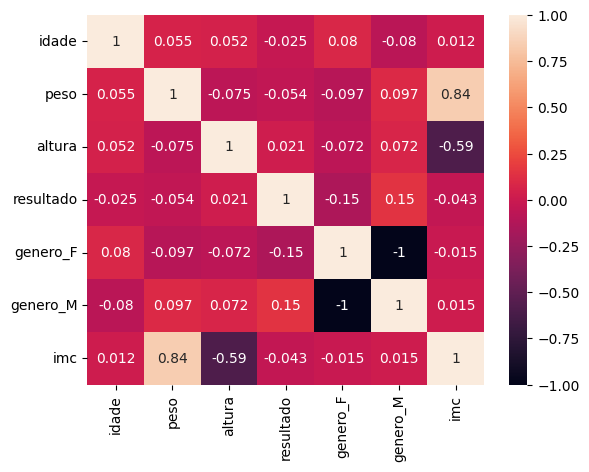

In [26]:
# Apresentar mapa de calor com Correlação entre as variáveis
sns.heatmap(df_exames.corr(), vmin=-1, vmax=1, annot=True)

<Axes: >

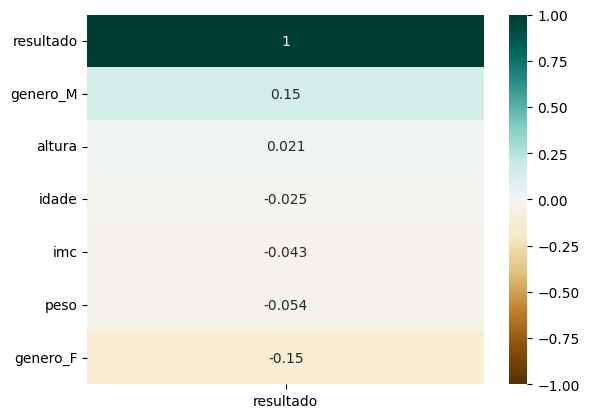

In [27]:
# Mapa de correlação só com a variável target (resultado)
sns.heatmap(df_exames.corr()[['resultado']].sort_values(by='resultado', ascending=False), vmin=-1, vmax=1,annot=True, cmap='BrBG' )

array([[<Axes: xlabel='idade', ylabel='idade'>,
        <Axes: xlabel='peso', ylabel='idade'>,
        <Axes: xlabel='altura', ylabel='idade'>,
        <Axes: xlabel='resultado', ylabel='idade'>,
        <Axes: xlabel='genero_F', ylabel='idade'>,
        <Axes: xlabel='genero_M', ylabel='idade'>,
        <Axes: xlabel='imc', ylabel='idade'>],
       [<Axes: xlabel='idade', ylabel='peso'>,
        <Axes: xlabel='peso', ylabel='peso'>,
        <Axes: xlabel='altura', ylabel='peso'>,
        <Axes: xlabel='resultado', ylabel='peso'>,
        <Axes: xlabel='genero_F', ylabel='peso'>,
        <Axes: xlabel='genero_M', ylabel='peso'>,
        <Axes: xlabel='imc', ylabel='peso'>],
       [<Axes: xlabel='idade', ylabel='altura'>,
        <Axes: xlabel='peso', ylabel='altura'>,
        <Axes: xlabel='altura', ylabel='altura'>,
        <Axes: xlabel='resultado', ylabel='altura'>,
        <Axes: xlabel='genero_F', ylabel='altura'>,
        <Axes: xlabel='genero_M', ylabel='altura'>,
        <Axes

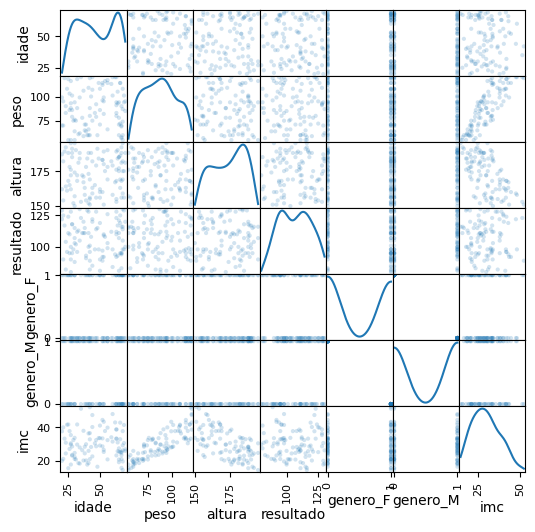

In [28]:
# Plot de Scatter (Dispersão) com Distribuição
pd.plotting.scatter_matrix(df_exames, alpha=0.2, figsize=(6,6), diagonal='kde')

array([[<Axes: title={'center': 'idade'}>,
        <Axes: title={'center': 'peso'}>,
        <Axes: title={'center': 'altura'}>,
        <Axes: title={'center': 'resultado'}>],
       [<Axes: title={'center': 'genero_F'}>,
        <Axes: title={'center': 'genero_M'}>,
        <Axes: title={'center': 'imc'}>, <Axes: >]], dtype=object)

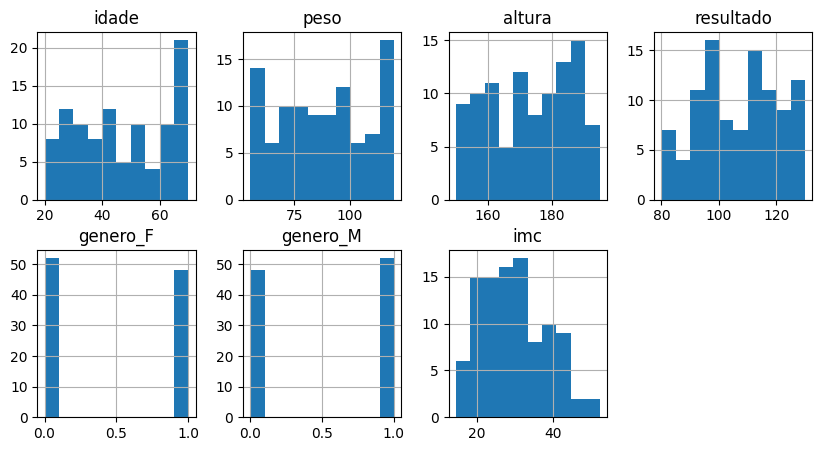

In [30]:
# Histograma de todas as variáveis
df_exames.hist(layout=(2,4), figsize=(10,5))

## Criação de features


In [24]:
# Criar uma feature nova
# IMC 
# IMC = peso (kg) / altura^2 (m)
df_exames['imc'] = (df_exames.peso / ((df_exames.altura/100)**2))

In [25]:
df_exames.head(10)

,idade,peso,altura,resultado,genero_F,genero_M,imc
0,46,83,165,98,0,1,30.486685
1,23,83,164,82,1,0,30.859607
2,39,71,154,93,0,1,29.937595
3,26,103,165,95,1,0,37.832874
4,27,55,176,100,0,1,17.755682
5,64,93,190,117,0,1,25.761773
6,21,70,182,90,1,0,21.132713
7,60,101,179,84,1,0,31.522112
8,63,83,189,92,1,0,23.235632
9,65,78,175,121,1,0,25.469388


In [ ]:
## Rodas os comandos de gráficos novamente

## Treinamento dos modelos

In [31]:
# Criar um exemplo simples para demonstração
dict_regressao = {'tempo_casa': [1,3,6,9,10,14,18], 'salario': [1500,3000,4500,6000,7000,8500,10000]}

In [32]:
df_regressao_simples = pd.DataFrame.from_dict(dict_regressao)

<Axes: xlabel='tempo_casa', ylabel='salario'>

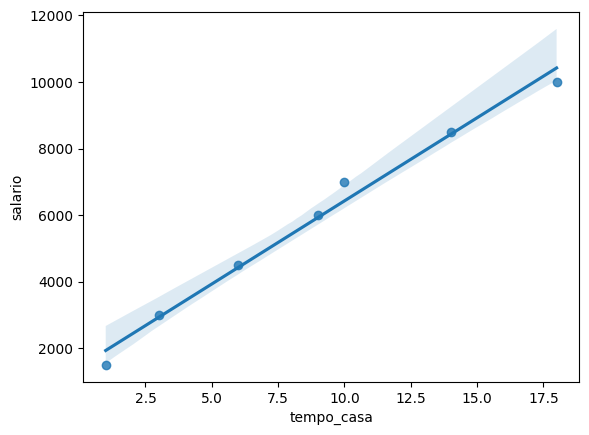

In [ ]:
sns.regplot(data=df_regressao_simples, x='tempo_casa', y='salario') # y = ax + b 

In [ ]:
# Voltando para o exemplo de diabetes
# Importar bibliotecas
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

In [38]:
# Modelo 1 - Sem IMC
X = df_exames.drop(columns=['imc', 'resultado'])
y = df_exames.resultado
X

,idade,peso,altura,genero_F,genero_M
0,46,83,165,0,1
1,23,83,164,1,0
2,39,71,154,0,1
3,26,103,165,1,0
4,27,55,176,0,1
...,...,...,...,...,...
95,52,96,183,1,0
96,68,108,169,1,0
97,21,95,154,0,1
98,41,109,173,0,1


In [39]:
# Dividir conjunto entre treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=51)

In [41]:
# Treinamento do modelo 1 - Regressão Linear
model_1 = LinearRegression().fit(X_train, y_train)


In [42]:
# Gerar predições do conjunto testes com base no Modelo 1
y_pred = model_1.predict(X_test)

In [43]:
y_pred

array([ 99.6684178 , 111.15467732, 113.11211654, 108.92788908,
       106.38206401, 107.30939688, 109.65461594, 112.00335574,
       111.06900447, 109.78672617, 112.35808062, 112.28232464,
       111.9380202 , 108.10634945,  98.35810505, 108.24066307,
       107.47444699, 107.86866238, 108.45528721, 106.47405474,
       108.68462818, 107.39800684, 105.52920918, 101.5310878 ,
       107.73027652, 103.02436766, 105.65307386, 112.03833836,
       105.49217347, 100.44933075])

In [46]:
# Métricas do Modelo 1
# R2 score - Conjunto de treinamento
# Quanto mais perto de 1 melhor
model_1.score(X_train, y_train)


0.06218388634297267

In [48]:
# R2 Score - Conjunto de testes
# model_1.score(X_test, y_test)
r2_score(y_test, y_pred)

-0.1364090447910642

In [49]:
# MAE (Mean Absolute Error)
mean_absolute_error(y_test, y_pred)

12.695569181179541

In [50]:
# Modelo 2 - Com IMC, sem peso e altura
X = pd.DataFrame(df_exames['imc'])
y = df_exames.resultado

In [51]:
# Dividir conjunto entre treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=51)

In [52]:
# Treinar o modelo 2 com regressão linear
model_2 = LinearRegression().fit(X_train, y_train)

In [53]:
# Gerar predição com base no modelo para o conjunto de testes
y_pred = model_2.predict(X_test)

In [54]:
model_2.coef_

array([-0.21677589])

In [55]:
model_2.intercept_

np.float64(112.15019229088837)

In [56]:
# Gerar métricas
# R2 score - conjunto de treinamento
model_2.score(X_train, y_train)

0.015285962664806862

In [ ]:
# R2 score - conjunto de testes
model_2.score(X_test, y_test)

-0.08898328562401758

In [58]:
# MAE (Mean Absolute Error)
mean_absolute_error(y_test, y_pred)

12.5056514070601

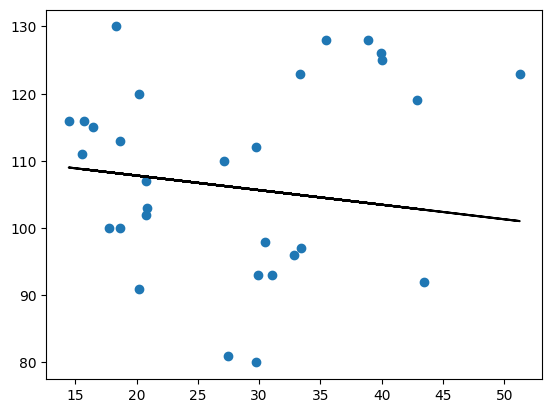

In [69]:
# Mostrar como a reta foi calculada
plt.pyplot.scatter(X_test, y_test)
plt.pyplot.plot(X_test, y_pred, color = 'k')